In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Vision Transformer

Everything this chapter has built so far consumed text. Yet nothing in the
transformer block *asks* what its tokens are: attention mixes vectors, the
feed-forward network transforms them, and neither cares whether those vectors
started life as subwords. This section makes the point concrete by feeding the
block pieces of an image.

For years the presumed answer to "transformers for vision?" was that images
are different. CNNs (that section) owned computer vision, and
their structural commitments, locality and translation equivariance
(that section), looked like exactly what images demand. Early
attempts kept those commitments: @ramachandran2019stand replaced
convolutions with local self-attention, whose specialized attention patterns
were hard to run fast on accelerators, and @cordonnier2020relationship
proved that self-attention *can* learn to behave like convolution,
demonstrating it with $2 \times 2$ patches too small for realistic images.
The *vision transformer* (ViT) of @Dosovitskiy.Beyer.Kolesnikov.ea.2021
dropped the caution: cut the image into $16 \times 16$ patches, embed each
patch as a token, and run an unmodified transformer encoder over the
resulting sequence. Trained on enough images (300 million of them), it beat
the best CNNs of the day.

We build that model here and train it on Fashion-MNIST, where the headline
result is that it *loses* to a CNN of the same parameter count. The loss is
the lesson: a convolutional network gets locality and translation
equivariance by construction, while a transformer must learn them from data,
and 60,000 images are not enough to close the gap that 300 million close
easily. Along the way we open the trained model and check whether it has
started learning what it was never told — that its 36 tokens came from a
$6 \times 6$ grid.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
from torch import nn

## Patches as Tokens

the figure depicts the architecture. It consists of a stem that
patchifies images, a body of transformer blocks, and a head that turns one
token's final representation into a class label.

![The vision transformer architecture. In this example, an image is split into nine patches. A special “&lt;cls&gt;” token and the nine flattened image patches are transformed via patch embedding and $\mathit{n}$ transformer blocks into ten representations, respectively. The “&lt;cls&gt;” representation is further transformed into the output label.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/vit.svg)

Consider an input image with height $h$, width $w$, and $c$ channels. With
patch height and width both set to $p$, the image is split into a sequence of
$m = hw/p^2$ patches, each flattened to a vector of length $cp^2$. A special
“&lt;cls&gt;” (class) token and the $m$ flattened patches are linearly
projected into $m + 1$ vectors and summed with learnable positional
embeddings. From here on the model is the encoder wiring of
that section: a stack of transformer blocks with no causal mask,
every token attending to every other, mapping $m + 1$ input vectors to
$m + 1$ output representations of the same dimension. Since the “&lt;cls&gt;”
token attends to all the image patches, its representation at the output of
the stack summarizes the whole image and is the one the classification head
reads.

Splitting an image into patches and linearly projecting the flattened patches
sounds like two operations, but they combine into one: a convolution whose
kernel size and stride both equal the patch size. Each output position of
such a convolution sees exactly one patch and computes exactly its linear
projection.

In [2]:
class PatchEmbedding(nn.Module):
    """Image-to-sequence stem of the vision transformer."""
    def __init__(self, img_size=96, patch_size=16, num_hiddens=512):
        super().__init__()
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        # A partial trailing patch would silently shrink the token grid
        assert img_size[0] % patch_size[0] == 0 and \
            img_size[1] % patch_size[1] == 0, \
            'image size must be divisible by the patch size'
        self.num_patches = (img_size[0] // patch_size[0]) * (
            img_size[1] // patch_size[1])
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size=patch_size,
                                  stride=patch_size)

    def forward(self, X):
        # Output shape: (batch size, no. of patches, no. of channels)
        return self.conv(X).flatten(2).transpose(1, 2)

In the following example, taking images with height and width of `img_size`
as inputs, the patch embedding outputs `(img_size//patch_size)**2` patches
that are linearly projected to vectors of length `num_hiddens`.

In [3]:
img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X = d2l.zeros(batch_size, 3, img_size, img_size)
d2l.check_shape(patch_emb(X),
                (batch_size, (img_size//patch_size)**2, num_hiddens))

This is the entire interface between vision and the transformer. Everything
that follows treats the patch vectors exactly as the rest of this chapter
treats token embeddings.

## The Vision Transformer Block

The body of the model is the transformer block of
that section in its pre-norm configuration: normalization
sits on each branch, right before multi-head attention and before the MLP,
and the residual stream runs uninterrupted. ViT adopted this arrangement just
as its training advantages were being established
[@baevski2018adaptive; @wang2019learning; @xiong2020layer], and its success
helped make pre-norm the default it is today.

Two details are specific to the vision variant. The MLP uses the Gaussian
error linear unit (GELU), a smooth relative of ReLU
[@Hendrycks.Gimpel.2016], and applies dropout after each of its two
linear layers — at ViT scale, unlike at LLM scale, regularization earns its
keep. And because every patch is a valid token that may look at every other,
the block needs no mask: the `valid_lens` argument of the
`d2l.MultiHeadAttention` from that section stays
`None` throughout this section.

In [4]:
class ViTBlock(nn.Module):
    """Pre-norm transformer block with a GELU MLP."""
    def __init__(self, num_hiddens, mlp_num_hiddens, num_heads, dropout,
                 use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(num_hiddens)
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.ln2 = nn.LayerNorm(num_hiddens)
        self.mlp = nn.Sequential(
            nn.LazyLinear(mlp_num_hiddens), nn.GELU(), nn.Dropout(dropout),
            nn.LazyLinear(num_hiddens), nn.Dropout(dropout))

    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))

As with every transformer block, the output shape equals the input shape, so
blocks stack without further ceremony.

In [5]:
X = d2l.ones((2, 100, 24))
encoder_blk = ViTBlock(24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X), X.shape)

## The Full Model

Assembling the pieces takes one class. Input images pass through a
`PatchEmbedding` instance; the “&lt;cls&gt;” token embedding, a learnable
parameter initialized to zeros, is prepended to the resulting sequence. The
sum with the positional embeddings goes through dropout, then through
`num_blks` stacked `ViTBlock` instances, and finally the head projects the
“&lt;cls&gt;” token's representation to the class logits.

The positional embeddings deserve a pause. The sinusoidal and rotary
constructions of that section encode positions along
a line, but a patch has a row *and* a column, and it is not obvious what a
hand-designed two-dimensional code should look like. ViT sidesteps the
question: the position embeddings are a freely learnable parameter,
initialized to small Gaussian noise as in the original recipe, one vector
per sequence position. At
initialization, the model therefore has no idea that patch 7 sits directly
left of patch 8 and directly above patch 13 — as far as it is concerned the
patches are an unordered set of vectors. Whatever spatial structure the
trained model uses, it must discover during training. We will check how far
it gets.

In [6]:
class ViT(d2l.Classifier):
    """Vision transformer."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1,
                 use_bias=False, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.patch_embedding = PatchEmbedding(
            img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(d2l.zeros(1, 1, num_hiddens))
        num_steps = self.patch_embedding.num_patches + 1  # Add the cls token
        # Positional embeddings are learnable, initialized to small noise
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_steps, num_hiddens) * 0.02)
        self.dropout = nn.Dropout(emb_dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, mlp_num_hiddens, num_heads, blk_dropout,
                use_bias))
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens),
                                  nn.Linear(num_hiddens, num_classes))

    def forward(self, X):
        X = self.patch_embedding(X)
        X = d2l.concat((self.cls_token.expand(X.shape[0], -1, -1), X), 1)
        X = self.dropout(X + self.pos_embedding)
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

Why read the class from the “&lt;cls&gt;” token rather than, say, averaging
all the patch representations? Both work. The extra token is a learned
querying device (through two rounds of attention it can *ask* for whatever
evidence the classification needs), and it matches the original recipe; the
exercises invite you to try the averaging variant.

## Training and What the Model Learns

### A First Run

We train a small ViT on Fashion-MNIST, resized to $96 \times 96$ so that a
$16 \times 16$ patch size yields $6 \times 6 = 36$ patch tokens. The recipe
is deliberately the one used for CNNs in that section: 10
epochs, batch size 128, plain SGD.

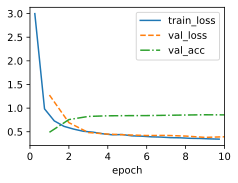

In [7]:
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(img_size, img_size))
trainer.fit(model, data)

In [8]:
vit_params = sum(p.numel() for p in model.parameters()
                 if p.requires_grad)
vit_acc = float(model.board.data['val_acc'][-1].y)
print(f'ViT: {vit_params/1e6:.1f}M parameters, '
      f'validation accuracy {vit_acc:.2f}')

ViT: 6.5M parameters, validation accuracy 0.86


The model trains without drama to a validation accuracy of about 86–87%.
Keep that number in mind; we will shortly see what a CNN of the same size
does with the same ten epochs.

### Do the Position Embeddings Discover the Grid?

First, though, let us look inside. The position embeddings started as noise,
and nothing in the training signal ever named a row or a column. In fully
trained ViTs the embeddings famously end up reflecting the grid anyway: in
the original paper's analysis, each position's embedding is most similar to
the embeddings of its spatial neighbors, with clear row and column bands —
two-dimensional structure induced by the data alone
[@Dosovitskiy.Beyer.Kolesnikov.ea.2021]. Does our small model already
show this? For each of the 36 patch positions we take its embedding vector,
compute its cosine similarity with the embeddings of all 36 positions, and
reshape those similarities into the $6 \times 6$ patch grid. Laying out the
36 resulting maps in the grid itself gives a picture in which position
$(i, j)$ of the big grid shows how similar position $(i, j)$'s embedding is
to everywhere else's.

mean cosine similarity: grid neighbors 0.05, distant positions -0.03


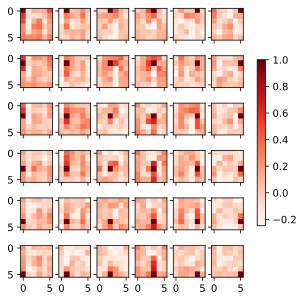

In [9]:
P = model.pos_embedding[0, 1:].detach().cpu()  # (36, 512): drop the cls slot
P = P / P.norm(dim=1, keepdim=True)
sim = P @ P.T                                  # Pairwise cosine similarities
coords = torch.stack(torch.meshgrid(
    torch.arange(6), torch.arange(6), indexing='ij'), -1).reshape(36, 2)
dist = (coords[:, None] - coords[None]).abs().amax(-1)  # Chebyshev distance
print(f'mean cosine similarity: grid neighbors {sim[dist == 1].mean():.2f}, '
      f'distant positions {sim[dist >= 3].mean():.2f}')
d2l.show_heatmaps(sim.reshape(6, 6, 6, 6), xlabel='', ylabel='',
                  figsize=(5, 5), cmap='Reds')

Each map's darkest cell is its own position, which is mere self-similarity;
the question is what surrounds it. The answer, after ten epochs, is: the
first faint traces of the grid and no more. The printed statistic makes it
precise: averaged over positions, immediate grid neighbors score slightly
positive cosine similarity while distant positions score slightly negative,
and several maps show a diffuse halo around their own cell or a weak band
along their own column — but the values are small and the pattern is easy
to miss without the summary statistics. Compare this with the crisp
row-and-column structure that emerges in fully trained ViTs, and the state
of our model is clear: the geometry it was never told is beginning to show
in its embeddings, and at this scale of data and training it has not
gotten far. Keep that in mind as we turn to an architecture that does not
need to learn the geometry at all.

### A Convolutional Baseline at the Same Budget

The ViT above has about 6.5 million parameters. To make the inductive-bias
comparison fair we build a CNN with the same budget, from the `Residual`
blocks of that section: the familiar $7 \times 7$ stem, then seven
residual blocks whose channel widths are chosen so that the total lands at
the ViT's parameter count. It trains on the identical data pipeline for the
identical ten epochs, with the learning rate that that section
established for this family.

In [10]:
class CompactResNet(d2l.Classifier):
    """A ResNet-style CNN parameter-matched to the ViT above."""
    def __init__(self, lr=0.01, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            d2l.Residual(64), d2l.Residual(64),
            d2l.Residual(128, strides=2), d2l.Residual(128),
            d2l.Residual(256, strides=2), d2l.Residual(256),
            d2l.Residual(512, strides=2),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.LazyLinear(num_classes))

    def forward(self, X):
        return self.net(X)

CNN: 6.5M parameters, validation accuracy 0.91
ViT: 6.5M parameters, validation accuracy 0.86


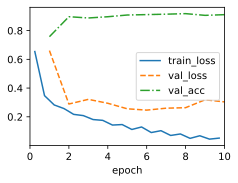

In [11]:
cnn = CompactResNet()
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(cnn, data)
cnn_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
cnn_acc = float(cnn.board.data['val_acc'][-1].y)
print(f'CNN: {cnn_params/1e6:.1f}M parameters, '
      f'validation accuracy {cnn_acc:.2f}')
print(f'ViT: {vit_params/1e6:.1f}M parameters, '
      f'validation accuracy {vit_acc:.2f}')

Same parameter count, same data, same number of epochs — and the CNN wins
by several points, about 90–92% against the ViT's 86–87%, a margin well
beyond the run-to-run noise of these ten-epoch runs. The gap is what the
convolutional prior is worth at this scale. Locality and translation
equivariance are a strong prior the CNN has by construction; the
transformer must buy the same facts with data, and we just watched how
slowly that purchase proceeds: after ten epochs its position embeddings
have barely begun to encode the grid. Nothing here says transformers are
worse at vision. It says that *at 60,000 images* the architecture with
the stronger prior wins,
and it sets the stakes for the discussion below, where the data budget
grows by four orders of magnitude and the verdict flips.

## Summary and Discussion

A vision transformer demonstrates, by construction, that the transformer
block does not care what its tokens are: one strided convolution turns an
image into a sequence, and everything downstream is the encoder stack this
chapter already built. The block is the pre-norm, GELU configuration of
that section; the only genuinely new parts are the patch
embedding, the “&lt;cls&gt;” readout, and position embeddings learned from
scratch.

The experiments carry the real content. At matched parameter count, data,
and training budget, the CNN wins, and it wins because of what it does not
have to learn: convolution builds in locality and translation equivariance
(that section), while the transformer must extract both from
60,000 images. Scale flips the verdict. Trained on 300 million images, ViTs
beat the best ResNets in image classification
[@Dosovitskiy.Beyer.Kolesnikov.ea.2021]: given enough data, learned
structure overtakes built-in structure, and the architecture with fewer
commitments has more room to improve. The crossover does not even require
new data — DeiT showed that aggressive augmentation and distillation make
ViTs competitive on ImageNet-1k alone [@touvron2021training],
manufacturing by transformation the invariances that convolution would have
supplied by design. A complementary line, Swin transformers, reinstates
convolution-like priors (local attention windows, hierarchical resolution)
partly to escape the quadratic cost of global attention
(that section) at high resolution [@liu2021swin].

In the years since, the plain ViT, not its convolution-flavored variants,
has become the standard vision backbone. Contrastively pretrained ViT
encoders such as CLIP's [@radford2021learning] supply the image side
of most vision-language models, and detection and segmentation systems
routinely sit on ViT features; the Image Models part (that section)
takes up these applications.

## Exercises

1. How does the value of `img_size` affect training time? Predict what
   halving `patch_size` to 8 does to the sequence length and to the cost of
   an attention layer (that section), then measure the
   time per epoch.
1. Instead of projecting the “&lt;cls&gt;” token representation to the
   output, project the averaged patch representations. Implement this change
   and see how it affects the accuracy.
1. Add data augmentation — random horizontal flips and random crops — to the
   training pipeline and retrain both the ViT and the CNN. Does the gap
   between them shrink? Relate what you find to the DeiT recipe.
1. Apply a fixed random permutation to the 36 patch tokens at test time
   (after patch embedding, leaving the position embeddings in place) and
   measure the accuracy of the trained ViT. What does the size of the drop
   tell you about how much the model relies on its position embeddings?
1. To fine-tune a trained ViT at a higher resolution, the standard trick is
   to interpolate its position embeddings: reshape the $36$ patch embeddings
   to $6 \times 6 \times d$, resize spatially to the new grid, and flatten
   back. Implement this for $144 \times 144$ inputs (a $9 \times 9$ grid)
   and verify that the model still classifies far better than chance
   without any retraining.